# Regime · 03 — Optimize candidate Earth simplification regimes

**Stage:** 4 — regime calibration (exploratory decision layer)

**Purpose.** Rank **all candidate regimes together** and pick the most scientifically defensible. A regime = `threshold_km2` × order-removal (`pre_remove ∈ {0,1,2}`) × optional **delta (order-gap) pruning** (`delta ∈ {none,3,4}`), giving 9 variants per threshold:

| | no delta | delta ≥ 3 | delta ≥ 4 |
|---|---|---|---|
| no pruning | `full` | `full_d3` | `full_d4` |
| remove order 1 | `trim` | `trim_d3` | `trim_d4` |
| remove order 1+2 | `ge3` | `ge3_d3` | `ge3_d4` |

These are **not** two families — they are one pool of possible regimes, evaluated under a single eligibility rule and ranked by one score. Delta is just another pruning parameter.

**Delta rule** (`channel_heads.pruning.prune_by_order_gap`, applied after order-removal via `apply_strategy`): at each confluence, prune the side branch if `main_trunk_order − side_branch_order ≥ delta`. **No side-branch-order cap.** Deltas tested: 3, 4.

**Eligibility (hard filters):** `length_retained ≥ 0.30` (permissive but non-collapsed), `median Strahler ≥ 2`, low-order pruning only (`pre_remove ≤ 2`). **Ranking:** by `scientific_score = 0.60·dd + 0.30·complexity + 0.10·length` (lower = better; length is a hard filter so it only tie-breaks).

**Inputs (read-only):** per-outlet sweep `regime_optimization/dd_master_sweep_delta_low.csv`; `MARS_DD_STATS` (Dd_hull median ≈ 0.224); Mars Strahler median = 3; `REGIMES` (frozen, annotation only).

**Outputs:** `regime_optimization/` — `regime_candidate_scores_with_constraints.csv`, `eligible_regimes.csv`, `top3_regimes.csv`, `excluded_regime_candidates.csv`, `pareto_regime_candidates.csv`, and figures (incl. the **top-3 VN** drawing).

**Gate notes.** Exploratory; frozen regimes/models/calibration artifacts untouched. Pareto is a **diagnostic only** (§2). Threshold capped at ≤ 0.5 km².

In [17]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display

from channel_heads.io.paths import PROJECT_ROOT
from channel_heads.dd_calibration import MARS_DD_STATS
from channel_heads.regimes import REGIMES

CALIB_DIR = PROJECT_ROOT / 'data/results/drainage_density_calibration/complexity_calibration'
OUT_DIR = PROJECT_ROOT / 'data/results/drainage_density_calibration/regime_optimization'
OUT_DIR.mkdir(parents=True, exist_ok=True)
STRAHLER_CSV = CALIB_DIR / 'earth_vs_mars_strahler_summary.csv'
SWEEP_CSV = next((p for p in [
    OUT_DIR / 'dd_master_sweep_delta_low.csv',
    OUT_DIR / 'dd_master_sweep_complexity_dense_low.csv',
    CALIB_DIR / 'dd_master_sweep_complexity.csv',
] if p.exists()), None)
assert SWEEP_CSV is not None, 'no per-outlet sweep CSV found'

LENGTH_FLOOR = 0.30
COMPLEXITY_FLOOR = 2
LOW_ORDER_MAX_PRE_REMOVE = 2
MAX_THRESHOLD_KM2 = 0.5

# representative basin for the top-3 VN drawing (high-order so delta is visible)
REPR_DEM = 'taiwan'
OUTLET_RANK = 0  # 0 = largest basin

VARIANT_SPEC = {
    'full': (0, 0), 'trim': (1, 0), 'ge3': (2, 0),
    'full_d3': (0, 3), 'full_d4': (0, 4),
    'trim_d3': (1, 3), 'trim_d4': (1, 4),
    'ge3_d3': (2, 3), 'ge3_d4': (2, 4),
}
PRUNE_LABEL = {0: 'no pruning', 1: 'remove order 1', 2: 'remove order 1+2'}

MARS_DD_MEDIAN = float(MARS_DD_STATS['median'])
MARS_S_MEDIAN = (float(pd.read_csv(STRAHLER_CSV)['mars_S_median'].median())
                 if STRAHLER_CSV.exists() else 3.0)

sweep = pd.read_csv(SWEEP_CSV)
sweep = sweep[sweep['threshold_km2'] <= MAX_THRESHOLD_KM2].copy()
print(f'Sweep source  — {SWEEP_CSV.name}  ({len(sweep)} rows)')
print(f'Mars targets  — Dd_hull median={MARS_DD_MEDIAN:.4f}  Strahler median={MARS_S_MEDIAN:.1f}')
print(f'Eligibility   — length_retained >= {LENGTH_FLOOR:.2f}, median Strahler >= {COMPLEXITY_FLOOR}, '
      f'pre_remove <= {LOW_ORDER_MAX_PRE_REMOVE}')

Sweep source  — dd_master_sweep_delta_low.csv  (5643 rows)
Mars targets  — Dd_hull median=0.2239  Strahler median=3.0
Eligibility   — length_retained >= 0.30, median Strahler >= 2, pre_remove <= 2


## 1 · Candidate regimes + scores

Each row = one candidate regime, aggregated to robust per-(threshold, variant) medians. `uses_delta` simply records whether order-gap pruning is on — it is a parameter, not a category. No core algorithm duplicated (Dd_hull/length/Strahler from `dd_calibration`, pruning from `pruning`).

In [18]:
def build_scored_candidates(sweep_df):
    avail = [k for k in VARIANT_SPEC if f'dd_hull_{k}' in sweep_df.columns]
    base_ok = sweep_df['status_full'].eq('ok') & (sweep_df['length_km_full'] > 0)
    rows = []
    for key in avail:
        pre, delta = VARIANT_SPEC[key]
        v_ok = base_ok & sweep_df[f'status_{key}'].eq('ok')
        ret = sweep_df[f'length_km_{key}'] / sweep_df['length_km_full']
        work = sweep_df.assign(_r=ret).loc[v_ok]
        for thr, g in work.groupby('threshold_km2'):
            dd = g[f'dd_hull_{key}'].replace([np.inf, -np.inf], np.nan).dropna()
            r = g['_r'].replace([np.inf, -np.inf], np.nan).dropna()
            s = g[f'max_strahler_{key}'].dropna()
            if dd.empty:
                continue
            rows.append({
                'threshold_km2': float(thr), 'pruning_variant': key,
                'pre_remove_max_order': pre,
                'order_gap_to_prune': (delta if delta else pd.NA),
                'uses_delta': bool(delta),
                'n_outlets': int(len(g)),
                'earth_dd_hull_median': float(dd.median()),
                'mars_dd_hull_median': MARS_DD_MEDIAN,
                'length_retained_median': float(r.median()) if not r.empty else np.nan,
                'max_strahler_median': float(s.median()) if not s.empty else np.nan,
                'mars_strahler_median': MARS_S_MEDIAN,
            })
    c = pd.DataFrame(rows)
    c['length_loss_median'] = 1.0 - c['length_retained_median']
    c['dd_score'] = (c['earth_dd_hull_median'] - MARS_DD_MEDIAN).abs() / MARS_DD_MEDIAN
    c['length_score'] = c['length_loss_median']
    c['complexity_score'] = (c['max_strahler_median'] - MARS_S_MEDIAN).abs() / MARS_S_MEDIAN
    return c

candidates = build_scored_candidates(sweep)
print(f'{len(candidates)} candidate regimes  variants={sorted(candidates.pruning_variant.unique())}')
candidates.to_csv(OUT_DIR / 'regime_candidate_scores.csv', index=False)

99 candidate regimes  variants=['full', 'full_d3', 'full_d4', 'ge3', 'ge3_d3', 'ge3_d4', 'trim', 'trim_d3', 'trim_d4']


## 2 · Pareto front — **diagnostic only**

Visualizes the dd/length/complexity trade-off; **not** used for selection. Pareto-optimal includes the single-objective extremes (e.g. the over-pruned corner that matches Mars Dd_hull only by collapsing the network), so it is a poor selector. Selection uses the explicit eligibility filters in §3–§4.

In [19]:
score_cols = [c for c in ['dd_score', 'length_score', 'complexity_score']
              if candidates[c].notna().any()]
def pareto_mask(df, cols):
    X = df[cols].to_numpy(float)
    keep = np.ones(len(X), bool)
    for i in range(len(X)):
        if keep[i]:
            for j in range(len(X)):
                if i != j and np.all(X[j] <= X[i]) and np.any(X[j] < X[i]):
                    keep[i] = False; break
    return keep
candidates['pareto_optimal'] = pareto_mask(candidates, score_cols)
print(f'{int(candidates.pareto_optimal.sum())} Pareto-optimal (diagnostic only)')

4 Pareto-optimal (diagnostic only)


## 3 · Eligibility (one rule for all regimes)

A regime is **eligible** if it passes every hard filter: `length_retained ≥ 0.30`, `median Strahler ≥ 2`, and low-order pruning only (`pre_remove ≤ 2`). The delta rule is applied without a side-branch cap. `length_retained` is a hard filter; `length_score` only tie-breaks among admissible regimes.

In [20]:
candidates['passes_length_filter'] = candidates['length_retained_median'] >= LENGTH_FLOOR
candidates['passes_complexity_floor'] = candidates['max_strahler_median'] >= COMPLEXITY_FLOOR
candidates['passes_low_order_filter'] = candidates['pre_remove_max_order'] <= LOW_ORDER_MAX_PRE_REMOVE
candidates['eligible'] = (candidates['passes_length_filter']
                          & candidates['passes_complexity_floor']
                          & candidates['passes_low_order_filter'])

def reason(r):
    if r['eligible']:
        return ''
    out = []
    if not r['passes_length_filter']:
        out.append(f"length_retained {r['length_retained_median']:.2f} < {LENGTH_FLOOR:.2f}")
    if not r['passes_complexity_floor']:
        out.append(f"median Strahler {r['max_strahler_median']:.0f} < {COMPLEXITY_FLOOR}")
    if not r['passes_low_order_filter']:
        out.append('pruning not low-order')
    return '; '.join(out) or 'not eligible'
candidates['exclusion_reason'] = candidates.apply(reason, axis=1)

have_cplx = candidates['complexity_score'].notna().any()
if have_cplx:
    candidates['scientific_score'] = (0.80 * candidates['dd_score']
                                      + 0.10 * candidates['complexity_score']
                                      + 0.10 * candidates['length_score'])
else:
    warnings.warn('complexity_score missing -> scientific_score = 0.80*dd + 0.20*length')
    candidates['scientific_score'] = 0.80 * candidates['dd_score'] + 0.20 * candidates['length_score']

candidates['frozen_regime'] = ''
for nm, rg in REGIMES.items():
    m = (np.isclose(candidates['threshold_km2'], rg.threshold_km2)
         & (candidates['pre_remove_max_order'] == rg.pre_remove_max_order)
         & candidates['order_gap_to_prune'].isna())
    candidates.loc[m, 'frozen_regime'] = nm
print(f'eligible regimes: {int(candidates.eligible.sum())} of {len(candidates)}')

eligible regimes: 64 of 99


## 4 · Top regimes (single ranked pool)

Rank **all eligible regimes together** by `scientific_score`; tie-break on (1) lower `dd_score`, (2) lower `complexity_score`, (3) higher `length_retained`. Top-3 is the recommendation.

In [21]:
SORT = ['scientific_score', 'dd_score', 'complexity_score', 'length_retained_median']
ASC = [True, True, True, False]
eligible = candidates[candidates['eligible']].sort_values(SORT, ascending=ASC).reset_index(drop=True)
top3_regimes = eligible.head(3).reset_index(drop=True)
view = ['threshold_km2', 'pruning_variant', 'pre_remove_max_order', 'order_gap_to_prune',
        'length_retained_median', 'earth_dd_hull_median', 'dd_score',
        'max_strahler_median', 'complexity_score', 'scientific_score', 'frozen_regime']
print('=== TOP-3 REGIMES ===')
display(top3_regimes[view])
print('=== all eligible (ranked) ===')
display(eligible[view])

=== TOP-3 REGIMES ===


,threshold_km2,pruning_variant,pre_remove_max_order,order_gap_to_prune,length_retained_median,earth_dd_hull_median,dd_score,max_strahler_median,complexity_score,scientific_score,frozen_regime
0,0.2,trim,1,<NA>,0.497784,1.325281,4.91951,3.0,0.0,3.985830,
1,0.2,trim_d4,1,4,0.496104,1.325281,4.91951,3.0,0.0,3.985997,
2,0.2,trim_d3,1,3,0.485470,1.325281,4.91951,3.0,0.0,3.987061,


=== all eligible (ranked) ===


,threshold_km2,pruning_variant,pre_remove_max_order,order_gap_to_prune,length_retained_median,earth_dd_hull_median,dd_score,max_strahler_median,complexity_score,scientific_score,frozen_regime
0,0.200,trim,1,<NA>,0.497784,1.325281,4.919510,3.0,0.000000,3.985830,
1,0.200,trim_d4,1,4,0.496104,1.325281,4.919510,3.0,0.000000,3.985997,
2,0.200,trim_d3,1,3,0.485470,1.325281,4.919510,3.0,0.000000,3.987061,
3,0.250,trim,1,<NA>,0.492073,1.344754,5.006489,2.0,0.333333,4.089317,regB
4,0.250,trim_d4,1,4,0.490083,1.344754,5.006489,2.0,0.333333,4.089516,
...,...,...,...,...,...,...,...,...,...,...,...
59,0.025,full_d4,0,4,0.926060,4.689837,19.947654,5.0,0.666667,16.032184,
60,0.025,full,0,<NA>,1.000000,5.107029,21.811090,5.0,0.666667,17.515538,
61,0.010,full_d3,0,3,0.623074,6.862348,29.651408,6.0,1.000000,23.858819,
62,0.010,full_d4,0,4,0.854563,9.195563,40.072961,6.0,1.000000,32.172912,


## 5 · Visualizations

Plain matplotlib. The final figure draws the actual valley networks of the top-3 regimes.

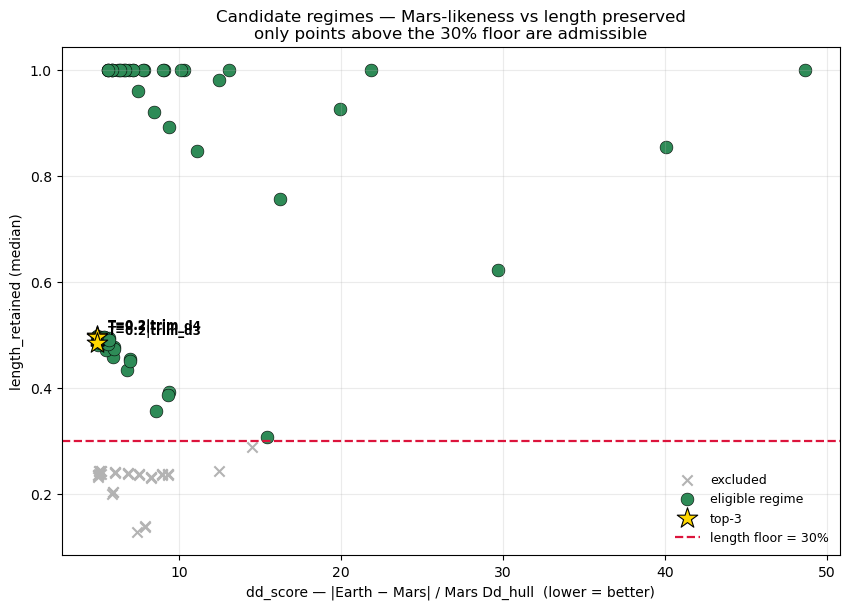

In [22]:
# Figure 1 — dd_score vs length_retained: eligible vs excluded; top-3 highlighted.
fig, ax = plt.subplots(figsize=(8.6, 6.2))
exc = candidates[~candidates.eligible]
elig = candidates[candidates.eligible]
ax.scatter(exc.dd_score, exc.length_retained_median, s=55, c='0.7', marker='x', label='excluded')
ax.scatter(elig.dd_score, elig.length_retained_median, s=85, c='#2e8b57', edgecolor='k',
           linewidths=0.4, label='eligible regime')
ax.scatter(top3_regimes.dd_score, top3_regimes.length_retained_median, s=240, marker='*',
           facecolor='gold', edgecolor='k', linewidths=0.8, zorder=5, label='top-3')
ax.axhline(LENGTH_FLOOR, color='crimson', ls='--', lw=1.6, label=f'length floor = {LENGTH_FLOOR:.0%}')
for _, r in top3_regimes.iterrows():
    ax.annotate(f"T={r.threshold_km2:g}|{r.pruning_variant}",
                (r.dd_score, r.length_retained_median), textcoords='offset points',
                xytext=(8, 6), fontsize=8.5, fontweight='bold')
ax.set_xlabel('dd_score — |Earth − Mars| / Mars Dd_hull  (lower = better)')
ax.set_ylabel('length_retained (median)')
ax.set_title('Candidate regimes — Mars-likeness vs length preserved\n'
             'only points above the 30% floor are admissible')
ax.legend(frameon=False, fontsize=9); ax.grid(True, alpha=0.25); fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_eligibility_dd_vs_length.png', dpi=150, bbox_inches='tight')
plt.show()

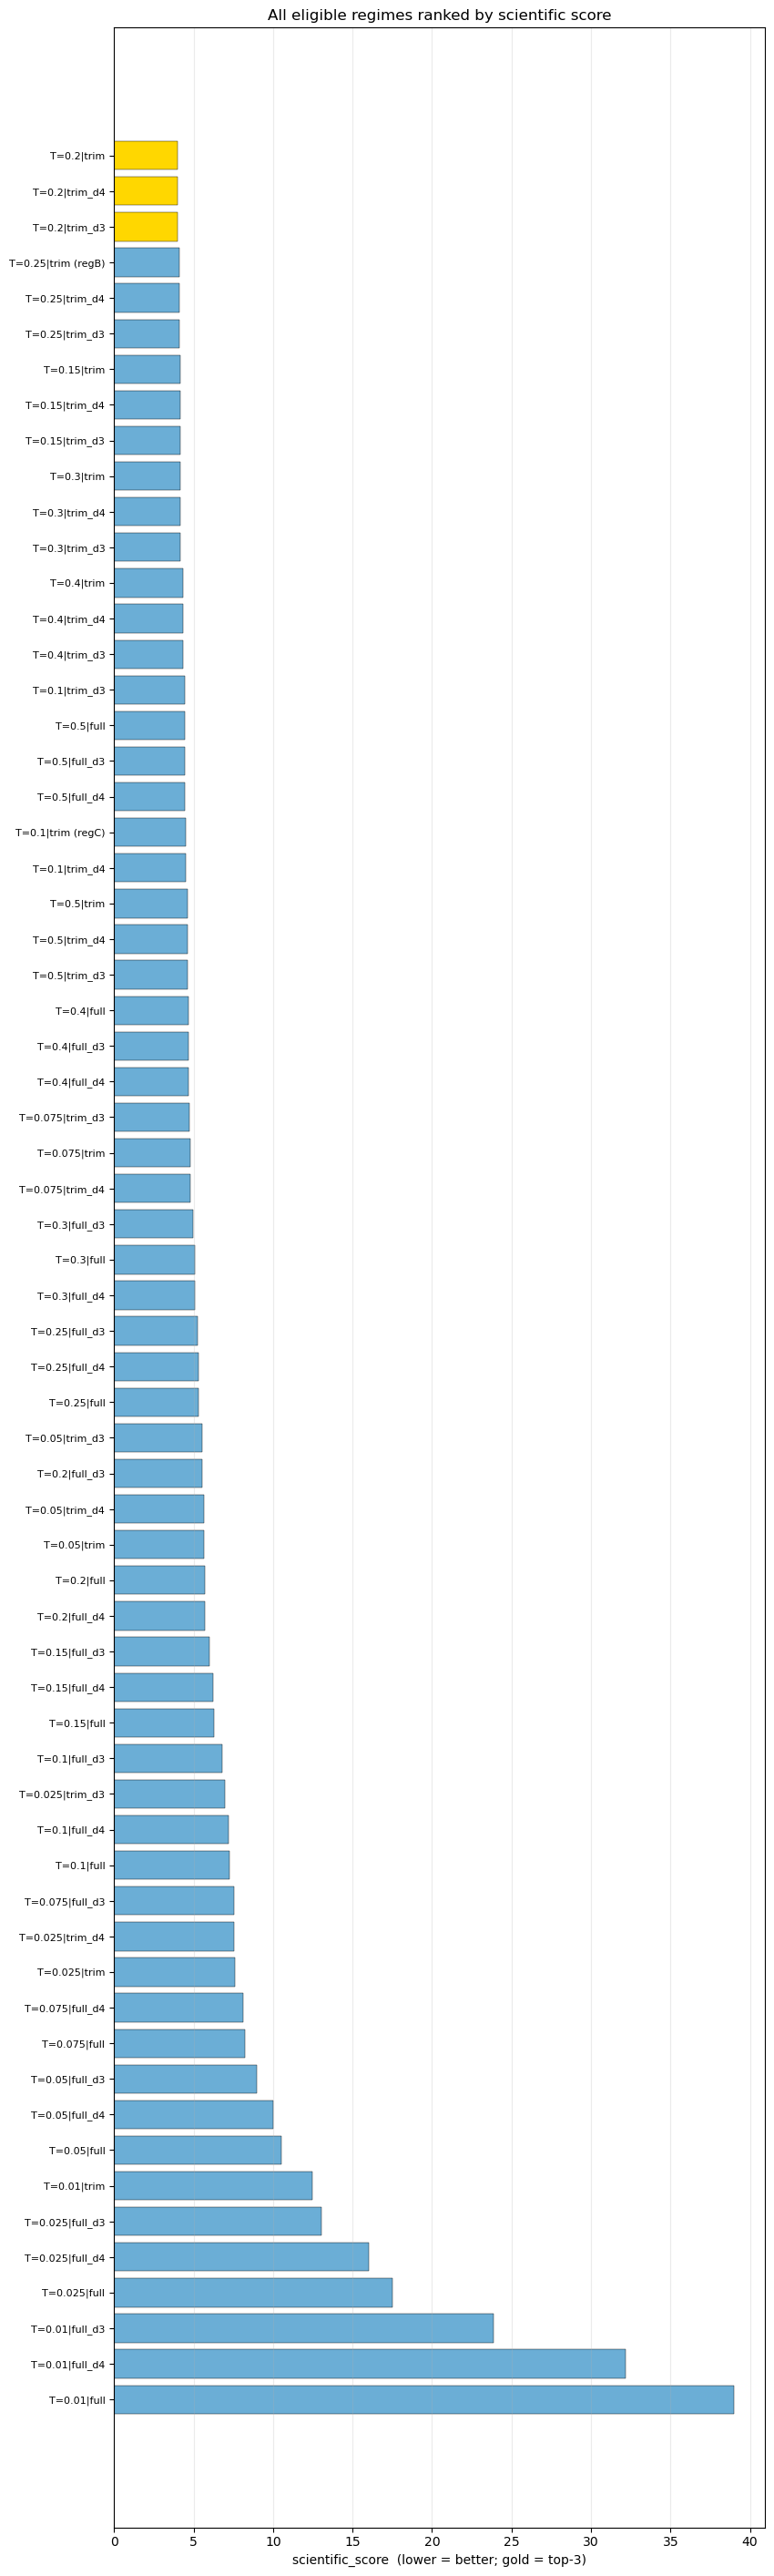

In [23]:
# Figure 2 — scientific_score ranking of ALL eligible regimes; top-3 in gold.
te = eligible.iloc[::-1]
labels = [f"T={r.threshold_km2:g}|{r.pruning_variant}"
          + (f' ({r.frozen_regime})' if str(getattr(r, 'frozen_regime', '') or '') else '')
          for r in te.itertuples()]
top_idx = set(top3_regimes.index)  # not used; color by rank position
colors = ['gold' if i >= len(te) - 3 else '#6baed6' for i in range(len(te))]
fig, ax = plt.subplots(figsize=(8.6, 0.42 * len(te) + 1.5))
ax.barh(range(len(te)), te.scientific_score, color=colors, edgecolor='k', linewidth=0.3)
ax.set_yticks(range(len(te))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('scientific_score  (lower = better; gold = top-3)')
ax.set_title('All eligible regimes ranked by scientific score')
ax.grid(True, axis='x', alpha=0.25); fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_regime_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

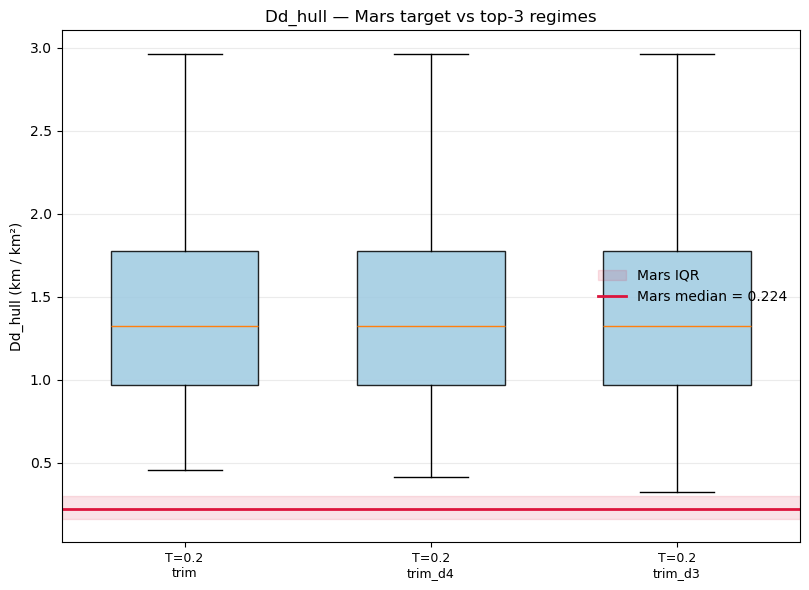

In [24]:
# Figure 3 — Dd_hull: Mars target vs top-3 (per-outlet distributions).
def outlet_dd_hull(threshold_km2, variant):
    if f'dd_hull_{variant}' not in sweep.columns:
        return np.array([])
    m = np.isclose(sweep.threshold_km2, threshold_km2) & sweep[f'status_{variant}'].eq('ok')
    return sweep.loc[m, f'dd_hull_{variant}'].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
groups, glabels = [], []
for r in top3_regimes.itertuples():
    v = outlet_dd_hull(r.threshold_km2, r.pruning_variant)
    if v.size:
        groups.append(v); glabels.append(f'T={r.threshold_km2:g}\n{r.pruning_variant}')
fig, ax = plt.subplots(figsize=(8.2, 6.0))
if groups:
    bp = ax.boxplot(groups, showfliers=False, widths=0.6, patch_artist=True)
    for p in bp['boxes']:
        p.set(facecolor='#9ecae1', alpha=0.85)
    ax.set_xticklabels(glabels, fontsize=9)
ax.axhspan(MARS_DD_STATS['q1'], MARS_DD_STATS['q3'], color='crimson', alpha=0.12, label='Mars IQR')
ax.axhline(MARS_DD_MEDIAN, color='crimson', lw=2, label=f'Mars median = {MARS_DD_MEDIAN:.3f}')
ax.set_ylabel('Dd_hull (km / km²)')
ax.set_title('Dd_hull — Mars target vs top-3 regimes')
ax.legend(frameon=False); ax.grid(True, axis='y', alpha=0.25); fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_ddhull_mars_vs_top3.png', dpi=150, bbox_inches='tight')
plt.show()

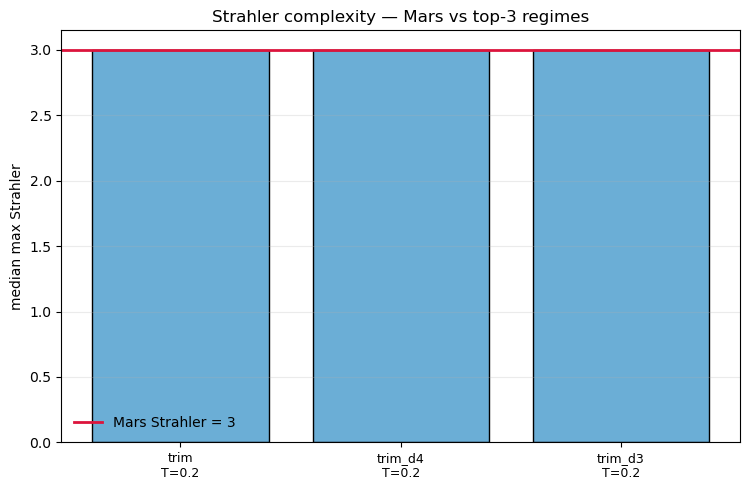

In [25]:
# Figure 4 — Strahler median: Mars vs top-3.
if len(top3_regimes):
    labels = [f"{r.pruning_variant}\nT={r.threshold_km2:g}" for r in top3_regimes.itertuples()]
    fig, ax = plt.subplots(figsize=(7.6, 5.0))
    ax.bar(range(len(top3_regimes)), top3_regimes.max_strahler_median, color='#6baed6', edgecolor='k')
    ax.axhline(MARS_S_MEDIAN, color='crimson', lw=2, label=f'Mars Strahler = {MARS_S_MEDIAN:.0f}')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('median max Strahler'); ax.set_title('Strahler complexity — Mars vs top-3 regimes')
    ax.legend(frameon=False); ax.grid(True, axis='y', alpha=0.25); fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig_strahler_mars_vs_top3.png', dpi=150, bbox_inches='tight')
    plt.show()

### Valley-network drawings of the top-3 regimes

Actual Earth valley networks under each top-3 regime on **one representative basin** (`REPR_DEM`, rank-`OUTLET_RANK`). **Grey** = full network at the threshold; **blue** = what the regime retains after order-removal (+ delta). Vector polylines via `channel_heads.pruning.apply_strategy` + `dd_calibration._stream_segments_xy`.

> **Global-median vs single-basin metrics.** The ranking and every `*_median` column use **robust medians across all basins**, so they are *not* the metrics of any one drawn basin. Each panel therefore shows **both** the global median Dd_hull *and* this representative basin's own Dd_hull / length_retained / Strahler — they differ because a single basin is not the population (e.g. all three top-3 regimes share global median Dd_hull ≈ 1.33, yet this basin's value varies with how much each regime prunes here). Per-basin values are saved to `top3_representative_basin_metrics.csv`.

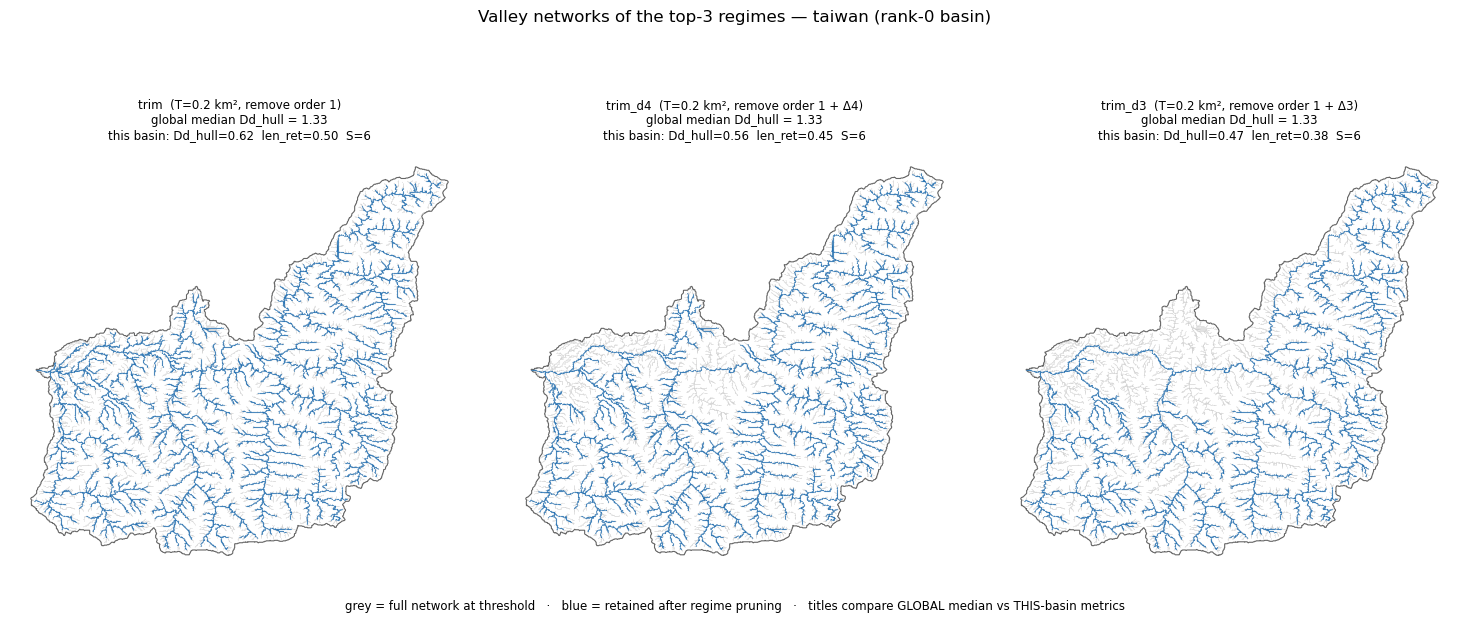

wrote top3_representative_basin_metrics.csv


,variant,threshold_km2,pre_remove_max_order,order_gap_to_prune,global_median_Dd_hull,representative_basin_Dd_hull,global_length_retained,representative_basin_length_retained,full_length,retained_length,hull_area,representative_basin_max_strahler,repr_dem,outlet_rank
0,trim,0.2,1,<NA>,1.325281,0.617781,0.497784,0.504943,4017.249964,2028.481022,3283.492884,6,taiwan,0
1,trim_d4,0.2,1,4,1.325281,0.555308,0.496104,0.452409,4017.249964,1817.438608,3272.848353,6,taiwan,0
2,trim_d3,0.2,1,3,1.325281,0.468628,0.485470,0.381791,4017.249964,1533.748769,3272.848353,6,taiwan,0


In [26]:
import topotoolbox as tt3
from channel_heads.basin_config import LOCAL_TO_PAPER_BASIN, get_basin_config
from channel_heads.io.paths import EXAMPLE_DEMS
from channel_heads.pruning import apply_strategy
from channel_heads.dd_calibration import (
    _basin_pixel_counts, _node_rowcol, _stream_segments_xy, _variant_payload,
    compute_basin_area_km2, compute_pixel_size_m_from_dem, compute_stream_length_km,
    compute_threshold_cells, linear_index_fortran, mask_boundary_xy,
)

cfg = get_basin_config(LOCAL_TO_PAPER_BASIN.get(REPR_DEM, REPR_DEM))
dem = tt3.read_tif(str(EXAMPLE_DEMS[REPR_DEM])); dem.z[dem.z < cfg['z_th']] = np.nan
px = compute_pixel_size_m_from_dem(dem, lat_deg=float(cfg['lat']))
fd = tt3.FlowObject(dem); n_rows = dem.z.shape[0]; valid = ~np.isnan(dem.z)
_scache = {}
def _stream(thr):
    if thr not in _scache:
        _scache[thr] = tt3.StreamObject(fd, threshold=compute_threshold_cells(thr, px))
    return _scache[thr]

# Fix the representative basin by its (threshold-invariant) pour point.
seed_thr = float(top3_regimes.threshold_km2.min())
s0 = _stream(seed_thr); r0, c0 = _node_rowcol(s0); o0 = np.flatnonzero(s0.streampoi('outlets'))
lin0 = np.array([linear_index_fortran(r0[o], c0[o], n_rows) for o in o0], dtype=np.int64)
lab0 = np.asarray(fd.drainagebasins(lin0).z); sizes = _basin_pixel_counts(lab0, valid, o0.size)
pick = int(np.argsort(sizes)[::-1][min(OUTLET_RANK, sizes.size - 1)])
seed_rc = (int(r0[o0[pick]]), int(c0[o0[pick]]))
seed_lin = linear_index_fortran(seed_rc[0], seed_rc[1], n_rows)
bmask = (np.asarray(fd.drainagebasins(np.array([seed_lin])).z) == 1) & valid
boundary = mask_boundary_xy(bmask, px)
basin_area_km2 = compute_basin_area_km2(bmask, px)

def regime_basin(threshold, pre, delta):
    """Segments + THIS-basin metrics for one regime (not global medians)."""
    s = _stream(threshold); rr, cc = _node_rowcol(s); outs = np.flatnonzero(s.streampoi('outlets'))
    d2 = (rr[outs] - seed_rc[0]) ** 2 + (cc[outs] - seed_rc[1]) ** 2
    oid = int(outs[int(np.argmin(d2))]); up = np.zeros(rr.shape[0], bool); up[oid] = True
    s_up = s.upstreamto(up)
    full_len = compute_stream_length_km(s_up, px)
    sv = apply_strategy(s_up, pre, delta)
    p = _variant_payload(sv, pixel_size_m=px, basin_area_km2=basin_area_km2,
                         full_length_km=full_len, full_edge_keys=None, want_geom=False)
    kept = _stream_segments_xy(sv, px) if sv is not None else np.empty((0, 2, 2))
    lr = (p['length_km'] / full_len) if full_len else float('nan')
    m = {'full_length': full_len, 'retained_length': p['length_km'],
         'representative_basin_length_retained': lr, 'hull_area': p['hull_area_km2'],
         'representative_basin_Dd_hull': p['dd_hull'],
         'representative_basin_max_strahler': p['max_strahler']}
    return _stream_segments_xy(s_up, px), kept, m

n = len(top3_regimes)
fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 5.8), squeeze=False)
rep_rows = []
for ax, (_, r) in zip(axes[0], top3_regimes.iterrows()):
    delta = int(r.order_gap_to_prune) if pd.notna(r.order_gap_to_prune) else 0
    full_segs, kept, m = regime_basin(r.threshold_km2, int(r.pre_remove_max_order), delta)
    if boundary is not None:
        ax.plot(boundary[:, 0], boundary[:, 1], color='k', lw=0.8, alpha=0.6)
    ax.add_collection(LineCollection(full_segs, colors='0.8', linewidths=0.5))
    ax.add_collection(LineCollection(kept, colors='#1f6fb4', linewidths=0.8))
    dl = f' + \u0394{delta}' if delta else ''
    rg = f' [{r.frozen_regime}]' if str(getattr(r, 'frozen_regime', '') or '') else ''
    ax.set_title(
        f'{r.pruning_variant}{rg}  (T={r.threshold_km2:g} km\u00b2, {PRUNE_LABEL[int(r.pre_remove_max_order)]}{dl})\n'
        f'global median Dd_hull = {r.earth_dd_hull_median:.2f}\n'
        f"this basin: Dd_hull={m['representative_basin_Dd_hull']:.2f}  "
        f"len_ret={m['representative_basin_length_retained']:.2f}  "
        f"S={m['representative_basin_max_strahler']}",
        fontsize=8.5)
    ax.set_aspect('equal'); ax.autoscale(); ax.axis('off')
    rep_rows.append({
        'variant': r.pruning_variant, 'threshold_km2': r.threshold_km2,
        'pre_remove_max_order': int(r.pre_remove_max_order),
        'order_gap_to_prune': (int(delta) if delta else pd.NA),
        'global_median_Dd_hull': r.earth_dd_hull_median,
        'representative_basin_Dd_hull': m['representative_basin_Dd_hull'],
        'global_length_retained': r.length_retained_median,
        'representative_basin_length_retained': m['representative_basin_length_retained'],
        'full_length': m['full_length'], 'retained_length': m['retained_length'],
        'hull_area': m['hull_area'],
        'representative_basin_max_strahler': m['representative_basin_max_strahler'],
        'repr_dem': REPR_DEM, 'outlet_rank': OUTLET_RANK,
    })
fig.suptitle(f'Valley networks of the top-3 regimes \u2014 {REPR_DEM} (rank-{OUTLET_RANK} basin)',
             fontsize=12, y=1.04)
fig.text(0.5, 0.005, 'grey = full network at threshold   \u00b7   blue = retained after regime pruning'
         '   \u00b7   titles compare GLOBAL median vs THIS-basin metrics', ha='center', fontsize=8.5)
fig.tight_layout(rect=[0, 0.04, 1, 0.88])
fig.savefig(OUT_DIR / 'fig_vn_top3_regimes.png', dpi=160, bbox_inches='tight')
plt.show()

rep_metrics = pd.DataFrame(rep_rows)
rep_metrics.to_csv(OUT_DIR / 'top3_representative_basin_metrics.csv', index=False)
print('wrote top3_representative_basin_metrics.csv'); display(rep_metrics)

## 6 · Save outputs

In [27]:
writes = {
    'regime_candidate_scores_with_constraints.csv': candidates,
    'eligible_regimes.csv': eligible,
    'top3_regimes.csv': top3_regimes,
    'excluded_regime_candidates.csv': candidates[~candidates.eligible],
    'pareto_regime_candidates.csv': candidates[candidates.pareto_optimal],
}
for name, df in writes.items():
    df.to_csv(OUT_DIR / name, index=False)
    print(f'OK  ({len(df):>3} rows)  {name}')

OK  ( 99 rows)  regime_candidate_scores_with_constraints.csv
OK  ( 64 rows)  eligible_regimes.csv
OK  (  3 rows)  top3_regimes.csv
OK  ( 35 rows)  excluded_regime_candidates.csv
OK  (  4 rows)  pareto_regime_candidates.csv


## 7 · Summary & scientific conclusion

In [28]:
print(f'Mars target Dd_hull median : {MARS_DD_MEDIAN:.3f}')
print(f'Mars target Strahler median: {MARS_S_MEDIAN:.0f}')
print(f'Total candidate regimes    : {len(candidates)}')
print(f'Passing length >= {LENGTH_FLOOR:.2f}     : {int(candidates.passes_length_filter.sum())}')
print(f'Eligible regimes           : {int(candidates.eligible.sum())}')
print()
print('Top-3 regimes:')
print(top3_regimes[view].to_string(index=False))
print()
print('Frozen regimes under the >=0.30 / low-order rule:')
fr = candidates[candidates.frozen_regime.astype(str).isin(['regA', 'regB', 'regC'])]
for r in fr.itertuples():
    verdict = 'ELIGIBLE' if r.eligible else f'EXCLUDED ({r.exclusion_reason})'
    print(f'  {r.frozen_regime}: T={r.threshold_km2:g} {r.pruning_variant} '
          f'len_ret={r.length_retained_median:.2f} S={r.max_strahler_median:.0f} -> {verdict}')

Mars target Dd_hull median : 0.224
Mars target Strahler median: 3
Total candidate regimes    : 99
Passing length >= 0.30     : 64
Eligible regimes           : 64

Top-3 regimes:
 threshold_km2 pruning_variant  pre_remove_max_order order_gap_to_prune  length_retained_median  earth_dd_hull_median  dd_score  max_strahler_median  complexity_score  scientific_score frozen_regime
           0.2            trim                     1               <NA>                0.497784              1.325281   4.91951                  3.0               0.0          3.985830              
           0.2         trim_d4                     1                  4                0.496104              1.325281   4.91951                  3.0               0.0          3.985997              
           0.2         trim_d3                     1                  3                0.485470              1.325281   4.91951                  3.0               0.0          3.987061              

Frozen regimes under the 

### Scientific conclusion

All threshold × pruning combinations (order-removal with or without delta) are treated as **one pool of candidate regimes** and ranked together. Under the defensible rule — preserve ≥ 30% of terrestrial valley-network length, keep median Strahler ≥ 2, prune only low orders — the leading regimes are light (`trim`/`full`-class, optionally with a conservative delta). `ge3`-style (remove order 1+2) regimes fall below the floor and/or collapse Strahler, and are excluded.

Delta (order-gap) pruning is a genuine parameter, not a separate category; it removes side branches far below the trunk order and is visible in the top-3 VN drawings. Even the most Mars-like admissible regime remains structurally denser than Mars's Dd_hull — confirming the Earth↔Mars Dd_hull gap is real, not a pruning artifact.

## 8 · Notes / TODO

1. Candidates come from the delta-augmented per-outlet sweep (`dd_master_sweep_delta_low.csv`), built by applying `channel_heads.pruning.apply_strategy(pre_remove, order_gap)` and measuring with `dd_calibration._variant_payload`. Deltas 3 and 4; **no side-branch-order cap**.
2. `LENGTH_FLOOR = 0.30` is the key knob; raising/lowering it re-derives the selection. `REPR_DEM` / `OUTLET_RANK` choose the basin drawn in the top-3 VN figure.
3. Frozen regimes are unchanged; this notebook only *evaluates* candidates.

## 9 · Final selection — regA–regE → `selected_regimes_AE.csv`

Diversity-deduped **top-5** of the eligible pool: one regime per `(order-removal, threshold)` base (near-identical delta twins collapsed), named regA…regE by `scientific_score` rank. This canonical table is the single source of truth consumed by `notebooks/pipeline/04_regime_selection.ipynb` and `channel_heads.regimes.load_selected_regimes`.

> **Foundation only.** Defines the new regimes; does **not** retrain models or rewire model-consuming downstream. The `*_reg{A,B,C}` artifacts were trained on the **old** frozen definitions and must be retrained for these regimes before inference is valid. Frozen `channel_heads/regimes.py` REGIMES are left unchanged.

In [ ]:
# Diversity-deduped top-5 -> regA..regE (uses the eligible pool + scientific_score above).
_sel = eligible.sort_values(
    ['scientific_score', 'dd_score', 'complexity_score', 'length_retained_median'],
    ascending=[True, True, True, False],
).drop_duplicates(subset=['pre_remove_max_order', 'threshold_km2'], keep='first').head(5)
_sel = _sel.reset_index(drop=True)
_sel['name'] = ['regA', 'regB', 'regC', 'regD', 'regE'][:len(_sel)]
selected_regimes = (_sel[['name', 'threshold_km2', 'pre_remove_max_order',
                          'order_gap_to_prune', 'pruning_variant', 'scientific_score',
                          'dd_score', 'length_retained_median', 'complexity_score']]
                    .rename(columns={'pruning_variant': 'variant',
                                     'length_retained_median': 'length_retained'}))
selected_regimes['order_gap_to_prune'] = selected_regimes['order_gap_to_prune'].fillna(0).astype(int)
selected_regimes.to_csv(OUT_DIR / 'selected_regimes_AE.csv', index=False)
print('wrote', (OUT_DIR / 'selected_regimes_AE.csv').name)
display(selected_regimes)